# 03 OCR - Single Image Working Pipeline (BBox + Ultralytics)

This notebook runs end-to-end inference for one image:
1) ROI detection (YOLO)
2) BBox crop pipeline with rotation correction
3) OCR digit detection (YOLO11m baseline) on 0 and 180 degrees
4) Orientation heuristics and final reading selection
5) Full debug visualizations + timing/RAM/VRAM stats

## What You Get

- Final predicted digit string for a single input image
- Stage timings: ROI stage, OCR+orientation stage, total
- Memory: RAM RSS and GPU memory usage (when CUDA is available)
- Visual trace: input -> ROI -> bbox debug stages -> OCR on both orientations -> final verdict

In [8]:
import os
import sys
import time
import ctypes
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO
from IPython.display import display

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.data.ocr_dataset import (
    OUT_H,
    OUT_W,
    crop_roi_from_detection,
    estimate_rotation_from_crop,
    _projection_score,
)
from models.data.unified_loader import load_water_meter_dataset_split

ROI_WEIGHTS = ROOT / "models/weights/roi_yolo/wm_yolo_roi_20260412_230832/weights/best.pt"
OCR_RUN_DIR = ROOT / "models/weights/baseline_yolo/yolo11m_20260414_194809"
OCR_WEIGHT_CANDIDATES = [
    OCR_RUN_DIR / "weights/best.pt",
    OCR_RUN_DIR / "weights/last.pt",
    OCR_RUN_DIR if OCR_RUN_DIR.suffix.lower() == ".pt" else None,
]
WM_PATH = ROOT / "WaterMetricsDATA/waterMeterDataset/WaterMeters"

ROI_IMGSZ = 640
ROI_MAX_DET = 16
ROI_CONF = 0.001

OCR_IMGSZ = 320
OCR_MAX_DET = 32
MAX_READING_DIGITS = 10

ULTRA_LAST_DRUM_X_ALIGN_FACTOR = 0.55
ULTRA_LAST_DRUM_MIN_Y_GAP_FACTOR = 0.25
ULTRA_OVERLAP_IOA_MIN = 0.65
ULTRA_OVERLAP_CENTER_FACTOR = 0.55

RED_CLUSTER_MIN_COVERAGE = 0.0025
RED_CLUSTER_LEFT_MAX_X = 0.43
RED_CLUSTER_RIGHT_MIN_X = 0.57
RED_BBOX_MIN_ACTIVE_PIXELS = 64
RED_BBOX_STRICTNESS = 0.08

LONG_TAIL_ZERO_MIN_DIGITS = 8
LONG_TAIL_ZERO_MIN_SUFFIX = 2
LEADING_ZERO_ORIENTATION_MIN = 3
NO_RED_SHORT_READING_MAX_DIGITS = 7

RED_BBOX_VOTE_WEIGHT = 0.85
STAT_TAIL_VOTE_WEIGHT = 0.09
LEADING_ZERO_VOTE_WEIGHT = 0.06
NO_RED_SHORT_READING_VOTE_WEIGHT = 0.07

np.set_printoptions(precision=4, suppress=True)
pd.options.display.max_colwidth = 120

print(f"ROOT: {ROOT}")
print(f"ROI weights exists: {ROI_WEIGHTS.exists()}")

ROOT: C:\Users\alike\WaterMeterCV
ROI weights exists: True


In [2]:
_ROI_MODEL_CACHE = None

_OCR_MODEL_CACHE = None





def bytes_to_mb(value):

    return float(value) / (1024.0 ** 2)





def resolve_ocr_weight_path():

    path = next((p for p in OCR_WEIGHT_CANDIDATES if p is not None and p.exists()), None)

    if path is None:

        checked = ", ".join(str(p) for p in OCR_WEIGHT_CANDIDATES if p is not None)

        raise FileNotFoundError(f"OCR weights not found. Checked: {checked}")

    return path





def get_roi_model():

    global _ROI_MODEL_CACHE

    if _ROI_MODEL_CACHE is None:

        if not ROI_WEIGHTS.exists():

            raise FileNotFoundError(f"ROI weights not found: {ROI_WEIGHTS}")

        _ROI_MODEL_CACHE = YOLO(str(ROI_WEIGHTS))

    return _ROI_MODEL_CACHE





def get_ocr_model():

    global _OCR_MODEL_CACHE

    if _OCR_MODEL_CACHE is None:

        weight_path = resolve_ocr_weight_path()

        _OCR_MODEL_CACHE = YOLO(str(weight_path))

        print(f"Loaded OCR weights: {weight_path}")

    return _OCR_MODEL_CACHE





def _ram_rss_bytes_windows():

    class PROCESS_MEMORY_COUNTERS_EX(ctypes.Structure):

        _fields_ = [

            ("cb", ctypes.c_ulong),

            ("PageFaultCount", ctypes.c_ulong),

            ("PeakWorkingSetSize", ctypes.c_size_t),

            ("WorkingSetSize", ctypes.c_size_t),

            ("QuotaPeakPagedPoolUsage", ctypes.c_size_t),

            ("QuotaPagedPoolUsage", ctypes.c_size_t),

            ("QuotaPeakNonPagedPoolUsage", ctypes.c_size_t),

            ("QuotaNonPagedPoolUsage", ctypes.c_size_t),

            ("PagefileUsage", ctypes.c_size_t),

            ("PeakPagefileUsage", ctypes.c_size_t),

            ("PrivateUsage", ctypes.c_size_t),

        ]



    counters = PROCESS_MEMORY_COUNTERS_EX()

    counters.cb = ctypes.sizeof(PROCESS_MEMORY_COUNTERS_EX)

    process = ctypes.windll.kernel32.GetCurrentProcess()

    ok = ctypes.windll.psapi.GetProcessMemoryInfo(process, ctypes.byref(counters), counters.cb)

    if not ok:

        return None

    return int(counters.WorkingSetSize)





def get_ram_rss_bytes():

    try:

        import psutil



        return int(psutil.Process(os.getpid()).memory_info().rss)

    except Exception:

        pass



    if os.name == "nt":

        return _ram_rss_bytes_windows()



    return None





def ensure_cuda_sync():

    if torch.cuda.is_available():

        torch.cuda.synchronize()





def reset_gpu_peak():

    if torch.cuda.is_available():

        ensure_cuda_sync()

        torch.cuda.reset_peak_memory_stats()





def gpu_peak_allocated_mb():

    if not torch.cuda.is_available():

        return 0.0

    ensure_cuda_sync()

    return bytes_to_mb(torch.cuda.max_memory_allocated())





def snapshot_resources():

    ensure_cuda_sync()

    rss = get_ram_rss_bytes()



    gpu_alloc = bytes_to_mb(torch.cuda.memory_allocated()) if torch.cuda.is_available() else 0.0

    gpu_reserved = bytes_to_mb(torch.cuda.memory_reserved()) if torch.cuda.is_available() else 0.0



    return {

        "ram_rss_mb": bytes_to_mb(rss) if rss is not None else np.nan,

        "gpu_alloc_mb": float(gpu_alloc),

        "gpu_reserved_mb": float(gpu_reserved),

    }





def delta_or_nan(after, before):

    if pd.isna(after) or pd.isna(before):

        return np.nan

    return float(after) - float(before)





print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():

    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU: NVIDIA GeForce GTX 1660 Ti


In [3]:
def detect_roi_bbox(image_bgr, roi_model):
    result = roi_model.predict(image_bgr, verbose=False, conf=ROI_CONF, imgsz=ROI_IMGSZ, max_det=ROI_MAX_DET)[0]
    boxes = getattr(result, "boxes", None)
    if boxes is None or len(boxes) == 0:
        return None

    idx = int(boxes.conf.argmax().item()) if hasattr(boxes, "conf") else 0
    b = boxes.xywhn[idx]
    conf = float(boxes.conf[idx].item()) if hasattr(boxes, "conf") else 0.0

    return {
        "bbox": (float(b[0]), float(b[1]), float(b[2]), float(b[3])),
        "conf": conf,
        "raw": result,
    }


def _est_crop(img, bbox, pad=0.3):
    h, w = img.shape[:2]
    cx, cy, bw, bh = bbox
    cx_px, cy_px = cx * w, cy * h
    bw_px, bh_px = bw * w, bh * h
    x1 = max(0, int(cx_px - bw_px * (1 + pad) / 2))
    y1 = max(0, int(cy_px - bh_px * (1 + pad) / 2))
    x2 = min(w, int(cx_px + bw_px * (1 + pad) / 2))
    y2 = min(h, int(cy_px + bh_px * (1 + pad) / 2))
    crop = img[y1:y2, x1:x2]
    if crop.size == 0:
        return np.zeros((OUT_H, OUT_W, 3), dtype=np.uint8)
    return crop


def _coarse90(crop):
    ch, cw = crop.shape[:2]
    if ch <= cw * 1.2:
        return crop, 0.0, "landscape"

    cw_rot = cv2.rotate(crop, cv2.ROTATE_90_CLOCKWISE)
    ccw_rot = cv2.rotate(crop, cv2.ROTATE_90_COUNTERCLOCKWISE)

    score_cw = _projection_score(cv2.cvtColor(cw_rot, cv2.COLOR_BGR2GRAY))
    score_ccw = _projection_score(cv2.cvtColor(ccw_rot, cv2.COLOR_BGR2GRAY))

    if score_cw >= score_ccw:
        return cw_rot, -90.0, "portrait: 90 CW"
    return ccw_rot, 90.0, "portrait: 90 CCW"


def _score_curve_full(crop, step=2.0):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    center = (w / 2.0, h / 2.0)

    angles = []
    scores = []
    for angle in np.arange(-90.0, 90.0 + step, step):
        matrix = cv2.getRotationMatrix2D(center, float(angle), 1.0)
        rot = cv2.warpAffine(gray, matrix, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
        angles.append(float(angle))
        scores.append(float(_projection_score(rot)))

    return angles, scores


def _rotated_crop_stages(img, bbox, total_angle, fine_angle, out_h=OUT_H, out_w=OUT_W):
    h, w = img.shape[:2]
    cx, cy, bw, bh = bbox
    cx_px, cy_px = cx * w, cy * h
    bw_px, bh_px = bw * w, bh * h

    matrix = cv2.getRotationMatrix2D((cx_px, cy_px), total_angle, 1.0)
    rotated = cv2.warpAffine(img, matrix, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

    fine_abs_rad = np.radians(np.abs(fine_angle))
    pad = 0.1 + 0.4 * float(np.abs(np.sin(2.0 * fine_abs_rad)))

    meter_long = max(bw_px, bh_px)
    meter_short = min(bw_px, bh_px)
    crop_w = meter_long * (1.0 + pad)
    crop_h = meter_short * (1.0 + pad)

    x1 = max(0, int(cx_px - crop_w / 2))
    y1 = max(0, int(cy_px - crop_h / 2))
    x2 = min(w, int(cx_px + crop_w / 2))
    y2 = min(h, int(cy_px + crop_h / 2))

    crop1 = rotated[y1:y2, x1:x2]
    if crop1.size == 0:
        zero = np.zeros((out_h, out_w, 3), dtype=np.uint8)
        return zero, None, zero, 0

    crop_final = crop1
    crop2 = None

    crop_h_px, crop_w_px = crop1.shape[:2]
    target_h2 = int(round(crop_w_px * out_h / out_w))

    if target_h2 >= out_h:
        center_x = (x1 + x2) / 2.0
        center_y = (y1 + y2) / 2.0

        x1_2 = max(0, int(round(center_x - crop_w_px / 2.0)))
        x2_2 = min(w, int(round(center_x + crop_w_px / 2.0)))
        y1_2 = max(0, int(round(center_y - target_h2 / 2.0)))
        y2_2 = min(h, int(round(center_y + target_h2 / 2.0)))

        c2 = rotated[y1_2:y2_2, x1_2:x2_2]
        if c2.size != 0:
            crop2 = c2
            crop_final = c2

    return crop1, crop2, crop_final, target_h2


def build_bbox_debug_stages(image_bgr, bbox, out_h=OUT_H, out_w=OUT_W):
    est_crop = _est_crop(image_bgr, bbox, pad=0.3)
    coarse_crop, coarse_angle, coarse_label = _coarse90(est_crop)

    angles, scores = _score_curve_full(coarse_crop, step=2.0)

    ch2, cw2 = coarse_crop.shape[:2]
    used_range = 45.0 if (cw2 > ch2 * 1.1) else 90.0
    fine_angle = float(estimate_rotation_from_crop(coarse_crop, angle_range=used_range))
    total_angle = float(coarse_angle + fine_angle)

    crop1, crop2, crop_pre_resize, target_h2 = _rotated_crop_stages(
        image_bgr,
        bbox,
        total_angle,
        fine_angle,
        out_h=out_h,
        out_w=out_w,
    )

    final_resize = cv2.resize(crop_pre_resize, (out_w, out_h))

    return {
        "est_crop": est_crop,
        "coarse_crop": coarse_crop,
        "coarse_angle": float(coarse_angle),
        "coarse_label": coarse_label,
        "angles": angles,
        "scores": scores,
        "used_range": float(used_range),
        "fine_angle": float(fine_angle),
        "total_angle": float(total_angle),
        "crop1": crop1,
        "crop2": crop2,
        "target_h2": int(target_h2),
        "pre_resize": crop_pre_resize,
        "final_resized": final_resize,
    }


def draw_bbox_norm(image_bgr, bbox, color=(0, 0, 255), thickness=2):
    vis = image_bgr.copy()
    h, w = vis.shape[:2]
    cx, cy, bw, bh = bbox

    x1 = int((cx - bw / 2) * w)
    y1 = int((cy - bh / 2) * h)
    x2 = int((cx + bw / 2) * w)
    y2 = int((cy + bh / 2) * h)

    x1 = max(0, min(w - 1, x1))
    y1 = max(0, min(h - 1, y1))
    x2 = max(0, min(w - 1, x2))
    y2 = max(0, min(h - 1, y2))

    cv2.rectangle(vis, (x1, y1), (x2, y2), color, thickness)
    return vis

In [4]:
def digits_only(text):
    return "".join(ch for ch in str(text) if ch.isdigit())


def safe_mean(values):
    return float(np.mean(values)) if values else 0.0


def leading_zero_count(text):
    d = digits_only(text)
    n = 0
    for ch in d:
        if ch == "0":
            n += 1
        else:
            break
    return n


def normalize_digits_for_stats(text):
    d = digits_only(text).lstrip("0")
    return d if d else "0"


def trailing_zero_count(text):
    n = 0
    for ch in reversed(str(text)):
        if ch == "0":
            n += 1
        else:
            break
    return n


def is_long_tail_zero_pattern(text):
    norm = normalize_digits_for_stats(text)
    return len(norm) >= LONG_TAIL_ZERO_MIN_DIGITS and trailing_zero_count(norm) >= LONG_TAIL_ZERO_MIN_SUFFIX


def is_no_red_upside_down_pattern(text, max_digits=NO_RED_SHORT_READING_MAX_DIGITS):
    d = digits_only(text)
    if not d:
        return False
    if len(d) > int(max_digits):
        return False
    return d[0] != "0" and d[-1] == "0"


def ultralytics_digit_rank(digit):
    d = int(digit)
    return 10 if d == 0 else d


def bbox_intersection_area(a, b):
    x_left = max(a["x1"], b["x1"])
    y_top = max(a["y1"], b["y1"])
    x_right = min(a["x2"], b["x2"])
    y_bottom = min(a["y2"], b["y2"])
    if x_right <= x_left or y_bottom <= y_top:
        return 0.0
    return float((x_right - x_left) * (y_bottom - y_top))


def bbox_area(d):
    return float(max(d["x2"] - d["x1"], 0.0) * max(d["y2"] - d["y1"], 0.0))


def boxes_are_nested_or_almost_nested(a, b):
    inter = bbox_intersection_area(a, b)
    if inter <= 0.0:
        return False

    area_a = max(bbox_area(a), 1e-6)
    area_b = max(bbox_area(b), 1e-6)
    ioa_small = inter / min(area_a, area_b)

    if ioa_small < ULTRA_OVERLAP_IOA_MIN:
        return False

    x_close = abs(a["cx"] - b["cx"]) <= ULTRA_OVERLAP_CENTER_FACTOR * max(a["w"], b["w"], 1e-6)
    y_close = abs(a["cy"] - b["cy"]) <= ULTRA_OVERLAP_CENTER_FACTOR * max(a["h"], b["h"], 1e-6)
    return bool(x_close and y_close)


def extract_ocr_detections(image_bgr, ocr_model):
    if image_bgr is None or image_bgr.size == 0:
        return []

    result = ocr_model.predict(image_bgr, verbose=False, imgsz=OCR_IMGSZ, max_det=OCR_MAX_DET)[0]
    boxes = getattr(result, "boxes", None)
    if boxes is None or len(boxes) == 0:
        return []

    digit_mask = boxes.cls <= 9
    digit_boxes = boxes[digit_mask]
    if len(digit_boxes) == 0:
        return []

    sorted_idx = digit_boxes.xywh[:, 0].argsort()
    detections = []

    for i in sorted_idx:
        xyxy = digit_boxes.xyxy[i].tolist()
        xywh = digit_boxes.xywh[i].tolist()
        if len(xyxy) < 4 or len(xywh) < 4:
            continue

        x1, y1, x2, y2 = [float(v) for v in xyxy[:4]]
        cx, cy, w, h = [float(v) for v in xywh[:4]]
        digit = int(digit_boxes.cls[i].item())
        score = float(digit_boxes.conf[i].item()) if hasattr(digit_boxes, "conf") else 0.0

        detections.append({
            "digit": digit,
            "conf": score,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "cx": cx,
            "cy": cy,
            "w": w,
            "h": h,
        })

    detections.sort(key=lambda d: d["cx"])
    return detections


def apply_ultralytics_overlap_heuristic(detections):
    dets = sorted(detections, key=lambda d: d["cx"])
    n = len(dets)
    if n < 2:
        return dets, {"applied": False, "reason": "not_enough_boxes"}

    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a_idx, b_idx):
        ra, rb = find(a_idx), find(b_idx)
        if ra != rb:
            parent[rb] = ra

    for i in range(n):
        for j in range(i + 1, n):
            if boxes_are_nested_or_almost_nested(dets[i], dets[j]):
                union(i, j)

    groups = {}
    for idx in range(n):
        root = find(idx)
        groups.setdefault(root, []).append(dets[idx])

    filtered = []
    applied_count = 0
    for group in groups.values():
        if len(group) == 1:
            filtered.append(group[0])
            continue

        applied_count += 1
        zeros = [g for g in group if int(g["digit"]) == 0]
        if zeros:
            chosen = max(zeros, key=lambda g: (float(g["conf"]), -bbox_area(g)))
        else:
            chosen = max(group, key=lambda g: (ultralytics_digit_rank(g["digit"]), float(g["conf"])))
        filtered.append(chosen)

    filtered.sort(key=lambda d: d["cx"])
    return filtered, {
        "applied": applied_count > 0,
        "reason": "overlap_group",
        "group_count": int(applied_count),
    }


def apply_ultralytics_last_drum_heuristic(detections):
    dets = sorted(detections, key=lambda d: d["cx"])
    if len(dets) < 2:
        return dets, {"applied": False, "reason": "not_enough_boxes"}

    a, b = dets[-2], dets[-1]
    w_ref = max(a["w"], b["w"], 1e-6)
    h_ref = max(a["h"], b["h"], 1e-6)

    x_close = abs(a["cx"] - b["cx"]) <= ULTRA_LAST_DRUM_X_ALIGN_FACTOR * w_ref
    y_split = abs(a["cy"] - b["cy"]) >= ULTRA_LAST_DRUM_MIN_Y_GAP_FACTOR * h_ref
    x_overlap = min(a["x2"], b["x2"]) > max(a["x1"], b["x1"])

    if not (x_close and y_split and x_overlap):
        return dets, {"applied": False, "reason": "not_vertical_pair"}

    rank_a = ultralytics_digit_rank(a["digit"])
    rank_b = ultralytics_digit_rank(b["digit"])
    if rank_a != rank_b:
        chosen = a if rank_a > rank_b else b
        reason = "digit_rank"
    elif a["conf"] != b["conf"]:
        chosen = a if a["conf"] >= b["conf"] else b
        reason = "confidence"
    elif a["cy"] != b["cy"]:
        chosen = a if a["cy"] < b["cy"] else b
        reason = "upper_tiebreak"
    else:
        chosen = a
        reason = "left_tiebreak"

    dropped = b if chosen is a else a
    filtered = dets[:-2] + [chosen]

    return filtered, {
        "applied": True,
        "reason": reason,
        "kept_digit": int(chosen["digit"]),
        "dropped_digit": int(dropped["digit"]),
    }


def predict_ocr_with_debug(image_bgr, ocr_model):
    det_raw = extract_ocr_detections(image_bgr, ocr_model)
    det_after_overlap, overlap_info = apply_ultralytics_overlap_heuristic(det_raw)
    det_final, last_drum_info = apply_ultralytics_last_drum_heuristic(det_after_overlap)

    pred_str = "".join(str(int(d["digit"])) for d in det_final)
    conf = safe_mean([float(d["conf"]) for d in det_final])

    if len(pred_str) > MAX_READING_DIGITS:
        overflow = len(pred_str) - MAX_READING_DIGITS
        penalty = max(0.0, 1.0 - (overflow / max(MAX_READING_DIGITS, 1)))
        pred_str = pred_str[:MAX_READING_DIGITS]
        conf *= penalty
        det_final = det_final[:MAX_READING_DIGITS]

    return {
        "pred": pred_str,
        "conf": float(conf),
        "detections_raw": det_raw,
        "detections_overlap": det_after_overlap,
        "detections_final": det_final,
        "overlap_heuristic": overlap_info,
        "last_drum_heuristic": last_drum_info,
    }


def estimate_red_horizontal_cluster_in_bboxes(image_bgr, detections, min_coverage=RED_CLUSTER_MIN_COVERAGE, min_active_pixels=RED_BBOX_MIN_ACTIVE_PIXELS):
    if image_bgr is None or image_bgr.size == 0 or not detections:
        return None

    b, g, r = cv2.split(image_bgr.astype(np.float32))
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1].astype(np.float32)
    v = hsv[:, :, 2].astype(np.float32)
    red_score = (r - np.maximum(g, b)) + 0.25 * s

    h, w = image_bgr.shape[:2]
    weighted_x_sum = 0.0
    weight_total = 0.0
    active_pixels = 0

    for d in detections:
        x1 = max(0, min(w - 1, int(round(d["x1"]))))
        y1 = max(0, min(h - 1, int(round(d["y1"]))))
        x2 = max(0, min(w - 1, int(round(d["x2"]))))
        y2 = max(0, min(h - 1, int(round(d["y2"]))))
        if x2 <= x1 or y2 <= y1:
            continue

        rr = r[y1:y2 + 1, x1:x2 + 1]
        gg = g[y1:y2 + 1, x1:x2 + 1]
        bb = b[y1:y2 + 1, x1:x2 + 1]
        vv = v[y1:y2 + 1, x1:x2 + 1]
        score_patch = red_score[y1:y2 + 1, x1:x2 + 1]

        base_mask = (vv >= 30.0) & (rr >= 40.0) & (rr >= gg * 1.02) & (rr >= bb * 1.02)
        if not np.any(base_mask):
            continue

        vals = score_patch[base_mask]
        thr = max(float(np.percentile(vals, 85.0)), 10.0)
        strong = base_mask & (score_patch >= thr)
        if not np.any(strong):
            continue

        _, xs = np.where(strong)
        weights = np.maximum(score_patch[strong] - thr, 0.0) + 1e-3

        weighted_x_sum += float(np.sum((xs.astype(np.float32) + float(x1)) * weights))
        weight_total += float(np.sum(weights))
        active_pixels += int(np.sum(strong))

    if active_pixels < int(min_active_pixels) or weight_total <= 1e-6:
        return None

    denom = float(max(w - 1, 1))
    x_norm = float(weighted_x_sum / (weight_total * denom))
    coverage = float(active_pixels / float(max(h * w, 1)))
    if coverage < float(min_coverage):
        return None

    return {"x_norm": x_norm, "coverage": coverage, "active_pixels": int(active_pixels)}


def get_stricter_red_bbox_thresholds(strictness=RED_BBOX_STRICTNESS):
    center = 0.5
    s = float(np.clip(strictness, 0.0, 0.30))

    left_dist = max(center - RED_CLUSTER_LEFT_MAX_X, 0.0)
    right_dist = max(RED_CLUSTER_RIGHT_MIN_X - center, 0.0)

    left_thr = RED_CLUSTER_LEFT_MAX_X - left_dist * s
    right_thr = RED_CLUSTER_RIGHT_MIN_X + right_dist * s
    min_cov = RED_CLUSTER_MIN_COVERAGE * (1.0 + s)
    min_pixels = int(np.ceil(RED_BBOX_MIN_ACTIVE_PIXELS * (1.0 + s)))

    return left_thr, right_thr, min_cov, min_pixels


def red_bbox_orientation_prior(image_bgr, ocr_model):
    detections = extract_ocr_detections(image_bgr, ocr_model)
    if not detections:
        return None

    detections, _ = apply_ultralytics_overlap_heuristic(detections)
    detections, _ = apply_ultralytics_last_drum_heuristic(detections)

    left_thr, right_thr, min_cov, min_pixels = get_stricter_red_bbox_thresholds()
    stats = estimate_red_horizontal_cluster_in_bboxes(
        image_bgr,
        detections,
        min_coverage=min_cov,
        min_active_pixels=min_pixels,
    )
    if stats is None:
        return None

    x_norm = stats["x_norm"]
    base = {
        **stats,
        "left_thr": float(left_thr),
        "right_thr": float(right_thr),
        "strict_min_coverage": float(min_cov),
        "strict_min_pixels": int(min_pixels),
    }

    if x_norm >= right_thr:
        return {**base, "angle": 0, "reason": "red_bbox_right"}
    if x_norm <= left_thr:
        return {**base, "angle": 180, "reason": "red_bbox_left"}
    return None


def _register_orientation_vote(votes, vote_details, name, angle, weight, extra=None):
    if angle not in (0, 180):
        return

    weight = float(max(weight, 0.0))
    if weight <= 0.0:
        return

    a = int(angle)
    votes[a] = float(votes.get(a, 0.0) + weight)

    detail = {"angle": a, "weight": weight}
    if isinstance(extra, dict):
        detail.update(extra)
    vote_details[name] = detail


def select_orientation_with_priors(pred0, pred180, roi_0_image_bgr, ocr_model):
    z0 = leading_zero_count(pred0["pred"])
    z180 = leading_zero_count(pred180["pred"])
    conf0 = float(pred0["conf"])
    conf180 = float(pred180["conf"])

    votes = {0: 0.0, 180: 0.0}
    vote_details = {}

    red_prior = red_bbox_orientation_prior(roi_0_image_bgr, ocr_model)
    if red_prior is not None:
        _register_orientation_vote(
            votes,
            vote_details,
            "red_bbox",
            int(red_prior["angle"]),
            RED_BBOX_VOTE_WEIGHT,
            {
                "reason": red_prior.get("reason"),
                "x_norm": float(red_prior.get("x_norm", 0.0)),
                "coverage": float(red_prior.get("coverage", 0.0)),
            },
        )

    short_tail0 = bool(is_no_red_upside_down_pattern(pred0["pred"]))
    short_tail180 = bool(is_no_red_upside_down_pattern(pred180["pred"]))
    if red_prior is None and short_tail0 and not short_tail180:
        _register_orientation_vote(
            votes,
            vote_details,
            "no_red_short_tail_zero",
            180,
            NO_RED_SHORT_READING_VOTE_WEIGHT,
            {"pattern_0": True, "pattern_180": False},
        )
    elif red_prior is None and short_tail180 and not short_tail0:
        _register_orientation_vote(
            votes,
            vote_details,
            "no_red_short_tail_zero",
            0,
            NO_RED_SHORT_READING_VOTE_WEIGHT,
            {"pattern_0": False, "pattern_180": True},
        )

    tail0 = bool(is_long_tail_zero_pattern(pred0["pred"]))
    tail180 = bool(is_long_tail_zero_pattern(pred180["pred"]))
    if tail0 and not tail180:
        _register_orientation_vote(
            votes,
            vote_details,
            "long_tail_zero",
            180,
            STAT_TAIL_VOTE_WEIGHT,
            {"tail0": True, "tail180": False},
        )
    elif tail180 and not tail0:
        _register_orientation_vote(
            votes,
            vote_details,
            "long_tail_zero",
            0,
            STAT_TAIL_VOTE_WEIGHT,
            {"tail0": False, "tail180": True},
        )

    if z0 >= LEADING_ZERO_ORIENTATION_MIN and z180 < LEADING_ZERO_ORIENTATION_MIN:
        _register_orientation_vote(
            votes,
            vote_details,
            "leading_zeros",
            0,
            LEADING_ZERO_VOTE_WEIGHT,
            {"leading_zeros_0": int(z0), "leading_zeros_180": int(z180)},
        )
    elif z180 >= LEADING_ZERO_ORIENTATION_MIN and z0 < LEADING_ZERO_ORIENTATION_MIN:
        _register_orientation_vote(
            votes,
            vote_details,
            "leading_zeros",
            180,
            LEADING_ZERO_VOTE_WEIGHT,
            {"leading_zeros_0": int(z0), "leading_zeros_180": int(z180)},
        )

    vote_score_0 = float(votes[0])
    vote_score_180 = float(votes[180])

    if vote_score_180 > vote_score_0 + 1e-9:
        selected_angle = 180
        reason = "vote_180"
    elif vote_score_0 > vote_score_180 + 1e-9:
        selected_angle = 0
        reason = "vote_0"
    elif conf180 > conf0:
        selected_angle = 180
        reason = "confidence_180_tiebreak"
    else:
        selected_angle = 0
        reason = "confidence_0_tiebreak"

    selected = pred180 if selected_angle == 180 else pred0

    selected_vote_contrib = {}
    for h_name, h_data in vote_details.items():
        h_angle = int(h_data.get("angle", -1))
        h_weight = float(h_data.get("weight", 0.0))
        selected_vote_contrib[h_name] = h_weight if h_angle == selected_angle else 0.0

    result = {
        "selected_angle": int(selected_angle),
        "selected_pred": selected["pred"],
        "selected_conf": float(selected["conf"]),
        "reason": reason,
        "conf_0": conf0,
        "conf_180": conf180,
        "leading_zeros_0": int(z0),
        "leading_zeros_180": int(z180),
        "vote_score_0": vote_score_0,
        "vote_score_180": vote_score_180,
        "vote_margin": float(abs(vote_score_0 - vote_score_180)),
        "vote_total": float(vote_score_0 + vote_score_180),
        "heuristic_votes": vote_details,
        "selected_vote_contrib": selected_vote_contrib,
        "no_red_short_pattern_0": bool(short_tail0),
        "no_red_short_pattern_180": bool(short_tail180),
    }

    if red_prior is not None:
        result["red_bbox_x_norm"] = float(red_prior.get("x_norm", 0.0))
        result["red_bbox_coverage"] = float(red_prior.get("coverage", 0.0))
        result["red_bbox_left_thr"] = float(red_prior.get("left_thr", RED_CLUSTER_LEFT_MAX_X))
        result["red_bbox_right_thr"] = float(red_prior.get("right_thr", RED_CLUSTER_RIGHT_MIN_X))

    return result


def build_orientation_checks(pred0, pred180, roi0, ocr_model):
    roi180 = cv2.rotate(roi0, cv2.ROTATE_180)
    red0 = red_bbox_orientation_prior(roi0, ocr_model)
    red180 = red_bbox_orientation_prior(roi180, ocr_model)

    checks = pd.DataFrame([
        {
            "orientation": "0",
            "pred": pred0["pred"],
            "conf": float(pred0["conf"]),
            "leading_zeros": int(leading_zero_count(pred0["pred"])),
            "long_tail_zero": bool(is_long_tail_zero_pattern(pred0["pred"])),
            "no_red_short_tail": bool(is_no_red_upside_down_pattern(pred0["pred"])),
            "red_prior": red0.get("reason") if red0 is not None else "none",
            "red_x_norm": float(red0.get("x_norm")) if red0 is not None else np.nan,
        },
        {
            "orientation": "180",
            "pred": pred180["pred"],
            "conf": float(pred180["conf"]),
            "leading_zeros": int(leading_zero_count(pred180["pred"])),
            "long_tail_zero": bool(is_long_tail_zero_pattern(pred180["pred"])),
            "no_red_short_tail": bool(is_no_red_upside_down_pattern(pred180["pred"])),
            "red_prior": red180.get("reason") if red180 is not None else "none",
            "red_x_norm": float(red180.get("x_norm")) if red180 is not None else np.nan,
        },
    ])

    return checks

In [5]:
def bgr2rgb(image_bgr):
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def draw_ocr_detections(image_bgr, detections, color=(0, 255, 0), thickness=2):
    vis = image_bgr.copy()
    h, w = vis.shape[:2]

    for d in detections:
        x1 = max(0, min(w - 1, int(round(d["x1"]))))
        y1 = max(0, min(h - 1, int(round(d["y1"]))))
        x2 = max(0, min(w - 1, int(round(d["x2"]))))
        y2 = max(0, min(h - 1, int(round(d["y2"]))))

        if x2 <= x1 or y2 <= y1:
            continue

        cv2.rectangle(vis, (x1, y1), (x2, y2), color, thickness)
        label = f"{int(d['digit'])}:{float(d['conf']):.2f}"
        cv2.putText(vis, label, (x1, max(14, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)

    return vis


def visualize_bbox_debug(original_image, roi_bbox, bbox_debug):
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    original_with_bbox = draw_bbox_norm(original_image, roi_bbox, color=(0, 0, 255), thickness=2)

    axes[0, 0].imshow(bgr2rgb(original_with_bbox))
    axes[0, 0].set_title("Input + ROI bbox")

    axes[0, 1].imshow(bgr2rgb(bbox_debug["est_crop"]))
    axes[0, 1].set_title("Estimation crop")

    axes[0, 2].imshow(bgr2rgb(bbox_debug["coarse_crop"]))
    axes[0, 2].set_title(f"After coarse 90 ({bbox_debug['coarse_label']})")

    ax_curve = axes[0, 3]
    ax_curve.plot(bbox_debug["angles"], bbox_debug["scores"], color="tab:blue", linewidth=1.6)
    used_range = float(bbox_debug["used_range"])
    ax_curve.axvspan(-used_range, used_range, alpha=0.12, color="green")
    ax_curve.axvline(float(bbox_debug["fine_angle"]), color="tab:red", linestyle="--")
    ax_curve.set_title("Projection score curve")
    ax_curve.set_xlabel("angle")

    axes[1, 0].imshow(bgr2rgb(bbox_debug["crop1"]))
    axes[1, 0].set_title(f"Rotated crop1 (total={bbox_debug['total_angle']:+.1f})")

    if bbox_debug["crop2"] is None:
        axes[1, 1].imshow(np.zeros((OUT_H, OUT_W, 3), dtype=np.uint8))
        axes[1, 1].text(
            0.5,
            0.5,
            f"crop2 skipped\nHc2={bbox_debug['target_h2']}",
            ha="center",
            va="center",
            transform=axes[1, 1].transAxes,
            color="white",
            fontsize=10,
        )
    else:
        axes[1, 1].imshow(bgr2rgb(bbox_debug["crop2"]))
        axes[1, 1].set_title(f"Crop2 (Hc2={bbox_debug['target_h2']})")

    axes[1, 2].imshow(bgr2rgb(bbox_debug["pre_resize"]))
    axes[1, 2].set_title("Pre-resize crop")

    axes[1, 3].imshow(bgr2rgb(bbox_debug["final_resized"]))
    axes[1, 3].set_title("Final ROI for OCR")

    for ax in axes.ravel():
        ax.axis("off")

    plt.suptitle("BBox debug pipeline: Input -> ROI -> corrected crop", fontsize=14)
    plt.tight_layout()
    plt.show()


def visualize_orientation_debug(roi0, roi180, pred0, pred180, selection):
    vis0 = draw_ocr_detections(roi0, pred0["detections_final"], color=(0, 255, 0))
    vis180 = draw_ocr_detections(roi180, pred180["detections_final"], color=(0, 255, 255))

    final_angle = int(selection["selected_angle"])
    final_image = vis0 if final_angle == 0 else vis180

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].imshow(bgr2rgb(vis0))
    axes[0, 0].set_title(f"Orientation 0\nPred={pred0['pred']} | Conf={pred0['conf']:.3f}")

    axes[0, 1].imshow(bgr2rgb(vis180))
    axes[0, 1].set_title(f"Orientation 180\nPred={pred180['pred']} | Conf={pred180['conf']:.3f}")

    axes[0, 2].imshow(bgr2rgb(final_image))
    axes[0, 2].set_title(
        f"Final selected (angle={selection['selected_angle']})\nPred={selection['selected_pred']} | Reason={selection['reason']}"
    )

    for ax in axes[0, :]:
        ax.axis("off")

    axes[1, 0].axis("off")
    axes[1, 1].axis("off")
    axes[1, 2].axis("off")

    vote_lines = [
        f"vote_score_0={selection['vote_score_0']:.3f}",
        f"vote_score_180={selection['vote_score_180']:.3f}",
        f"vote_margin={selection['vote_margin']:.3f}",
        f"leading_zeros_0={selection['leading_zeros_0']}",
        f"leading_zeros_180={selection['leading_zeros_180']}",
        f"no_red_short_0={selection['no_red_short_pattern_0']}",
        f"no_red_short_180={selection['no_red_short_pattern_180']}",
    ]

    contrib_lines = [
        "selected_vote_contrib:",
    ]
    for key, val in selection.get("selected_vote_contrib", {}).items():
        contrib_lines.append(f"  {key}={float(val):.3f}")

    heur_lines = [
        "heuristic_votes:",
    ]
    for name, data in selection.get("heuristic_votes", {}).items():
        heur_lines.append(f"  {name}: angle={data.get('angle')} weight={float(data.get('weight', 0.0)):.3f}")

    axes[1, 0].text(0.0, 1.0, "\n".join(vote_lines), va="top", fontsize=11, family="monospace")
    axes[1, 1].text(0.0, 1.0, "\n".join(contrib_lines), va="top", fontsize=11, family="monospace")
    axes[1, 2].text(0.0, 1.0, "\n".join(heur_lines), va="top", fontsize=11, family="monospace")

    plt.suptitle("OCR on 0/180 + orientation heuristics and final verdict", fontsize=14)
    plt.tight_layout()
    plt.show()

In [6]:
def run_single_image_pipeline(image_path, show_visualizations=True):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise ValueError(f"Failed to read image: {image_path}")

    roi_model = get_roi_model()
    ocr_model = get_ocr_model()

    total_t0 = time.perf_counter()
    resources_start = snapshot_resources()

    reset_gpu_peak()
    s1_t0 = time.perf_counter()

    roi_info = detect_roi_bbox(image_bgr, roi_model)
    if roi_info is None:
        raise RuntimeError("ROI was not detected on input image.")

    bbox_debug = build_bbox_debug_stages(image_bgr, roi_info["bbox"], out_h=OUT_H, out_w=OUT_W)
    roi_crop_0 = bbox_debug["final_resized"]

    stage1_ms = (time.perf_counter() - s1_t0) * 1000.0
    resources_after_stage1 = snapshot_resources()
    stage1_gpu_peak_mb = gpu_peak_allocated_mb()

    reset_gpu_peak()
    s2_t0 = time.perf_counter()

    pred0 = predict_ocr_with_debug(roi_crop_0, ocr_model)
    roi_crop_180 = cv2.rotate(roi_crop_0, cv2.ROTATE_180)
    pred180 = predict_ocr_with_debug(roi_crop_180, ocr_model)

    selection = select_orientation_with_priors(pred0, pred180, roi_crop_0, ocr_model)
    orientation_checks = build_orientation_checks(pred0, pred180, roi_crop_0, ocr_model)

    stage2_ms = (time.perf_counter() - s2_t0) * 1000.0
    resources_after_stage2 = snapshot_resources()
    stage2_gpu_peak_mb = gpu_peak_allocated_mb()

    total_ms = (time.perf_counter() - total_t0) * 1000.0

    final_angle = int(selection["selected_angle"])
    final_reading = str(selection["selected_pred"])
    final_detections = pred0["detections_final"] if final_angle == 0 else pred180["detections_final"]

    timing_df = pd.DataFrame([
        {"stage": "stage1_roi_and_bbox", "time_ms": float(stage1_ms)},
        {"stage": "stage2_ocr_orientation", "time_ms": float(stage2_ms)},
        {"stage": "total", "time_ms": float(total_ms)},
    ])

    resources_df = pd.DataFrame([
        {
            "stage": "stage1",
            "ram_start_mb": float(resources_start["ram_rss_mb"]),
            "ram_end_mb": float(resources_after_stage1["ram_rss_mb"]),
            "ram_delta_mb": delta_or_nan(resources_after_stage1["ram_rss_mb"], resources_start["ram_rss_mb"]),
            "gpu_alloc_start_mb": float(resources_start["gpu_alloc_mb"]),
            "gpu_alloc_end_mb": float(resources_after_stage1["gpu_alloc_mb"]),
            "gpu_alloc_delta_mb": float(resources_after_stage1["gpu_alloc_mb"] - resources_start["gpu_alloc_mb"]),
            "gpu_reserved_start_mb": float(resources_start["gpu_reserved_mb"]),
            "gpu_reserved_end_mb": float(resources_after_stage1["gpu_reserved_mb"]),
            "gpu_reserved_delta_mb": float(resources_after_stage1["gpu_reserved_mb"] - resources_start["gpu_reserved_mb"]),
            "gpu_peak_alloc_mb": float(stage1_gpu_peak_mb),
        },
        {
            "stage": "stage2",
            "ram_start_mb": float(resources_after_stage1["ram_rss_mb"]),
            "ram_end_mb": float(resources_after_stage2["ram_rss_mb"]),
            "ram_delta_mb": delta_or_nan(resources_after_stage2["ram_rss_mb"], resources_after_stage1["ram_rss_mb"]),
            "gpu_alloc_start_mb": float(resources_after_stage1["gpu_alloc_mb"]),
            "gpu_alloc_end_mb": float(resources_after_stage2["gpu_alloc_mb"]),
            "gpu_alloc_delta_mb": float(resources_after_stage2["gpu_alloc_mb"] - resources_after_stage1["gpu_alloc_mb"]),
            "gpu_reserved_start_mb": float(resources_after_stage1["gpu_reserved_mb"]),
            "gpu_reserved_end_mb": float(resources_after_stage2["gpu_reserved_mb"]),
            "gpu_reserved_delta_mb": float(resources_after_stage2["gpu_reserved_mb"] - resources_after_stage1["gpu_reserved_mb"]),
            "gpu_peak_alloc_mb": float(stage2_gpu_peak_mb),
        },
        {
            "stage": "total",
            "ram_start_mb": float(resources_start["ram_rss_mb"]),
            "ram_end_mb": float(resources_after_stage2["ram_rss_mb"]),
            "ram_delta_mb": delta_or_nan(resources_after_stage2["ram_rss_mb"], resources_start["ram_rss_mb"]),
            "gpu_alloc_start_mb": float(resources_start["gpu_alloc_mb"]),
            "gpu_alloc_end_mb": float(resources_after_stage2["gpu_alloc_mb"]),
            "gpu_alloc_delta_mb": float(resources_after_stage2["gpu_alloc_mb"] - resources_start["gpu_alloc_mb"]),
            "gpu_reserved_start_mb": float(resources_start["gpu_reserved_mb"]),
            "gpu_reserved_end_mb": float(resources_after_stage2["gpu_reserved_mb"]),
            "gpu_reserved_delta_mb": float(resources_after_stage2["gpu_reserved_mb"] - resources_start["gpu_reserved_mb"]),
            "gpu_peak_alloc_mb": float(max(stage1_gpu_peak_mb, stage2_gpu_peak_mb)),
        },
    ])

    print(f"Input image: {image_path}")
    print(f"ROI conf: {roi_info['conf']:.4f}")
    print(f"Final angle: {final_angle}")
    print(f"Final reading: {final_reading}")

    display(timing_df)
    display(resources_df)
    display(orientation_checks)

    if show_visualizations:
        visualize_bbox_debug(image_bgr, roi_info["bbox"], bbox_debug)
        visualize_orientation_debug(roi_crop_0, roi_crop_180, pred0, pred180, selection)

    return {
        "image_path": image_path,
        "roi_bbox": roi_info["bbox"],
        "roi_conf": float(roi_info["conf"]),
        "bbox_debug": bbox_debug,
        "pred0": pred0,
        "pred180": pred180,
        "selection": selection,
        "orientation_checks": orientation_checks,
        "timing_df": timing_df,
        "resources_df": resources_df,
        "final_reading": final_reading,
        "final_angle": final_angle,
        "final_detections": final_detections,
    }

Using IMAGE_PATH=C:\Users\alike\WaterMeterCV\WaterMetricsDATA\waterMeterDataset\WaterMeters\images\id_586_value_199_502.jpg
Input image: C:\Users\alike\WaterMeterCV\WaterMetricsDATA\waterMeterDataset\WaterMeters\images\id_586_value_199_502.jpg
ROI conf: 0.8504
Final angle: 180
Final reading: 00199507


,stage,time_ms
0,stage1_roi_and_bbox,486.0510
1,stage2_ocr_orientation,73.5024
2,total,560.7953


,stage,ram_start_mb,ram_end_mb,ram_delta_mb,gpu_alloc_start_mb,gpu_alloc_end_mb,gpu_alloc_delta_mb,gpu_reserved_start_mb,gpu_reserved_end_mb,gpu_reserved_delta_mb,gpu_peak_alloc_mb
0,stage1,1306.433594,1311.972656,5.539062,119.790039,119.791016,0.000977,156.0,156.0,0.0,137.915039
1,stage2,1311.972656,1311.972656,0.000000,119.791016,119.791016,0.000000,156.0,156.0,0.0,129.518066
2,total,1306.433594,1311.972656,5.539062,119.790039,119.791016,0.000977,156.0,156.0,0.0,137.915039


,orientation,pred,conf,leading_zeros,long_tail_zero,no_red_short_tail,red_prior,red_x_norm
0,0,70566100,0.708300,0,True,False,red_bbox_left,0.254633
1,180,00199507,0.774598,2,False,False,red_bbox_right,0.750790


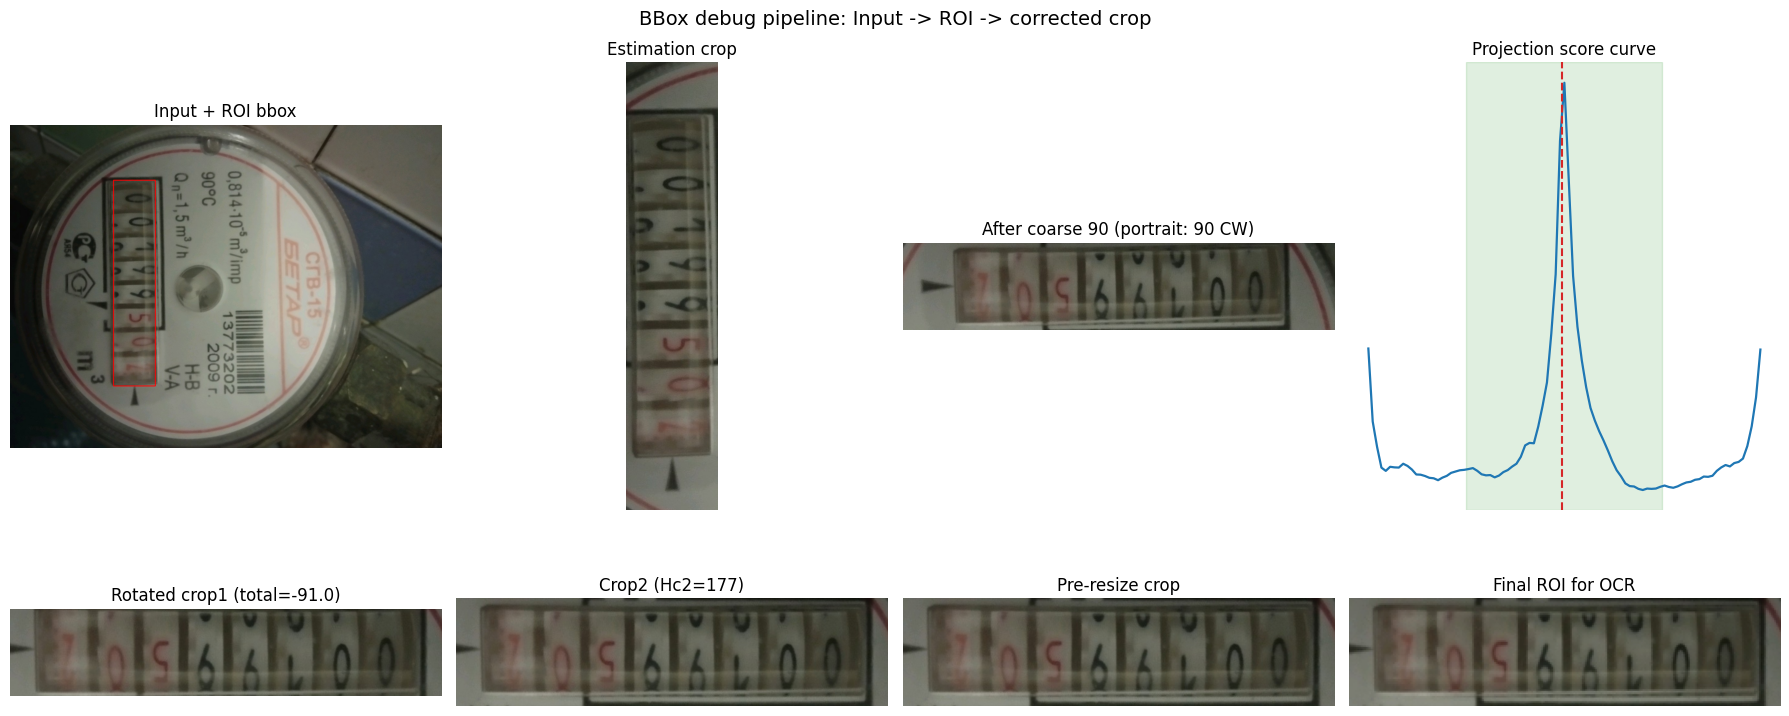

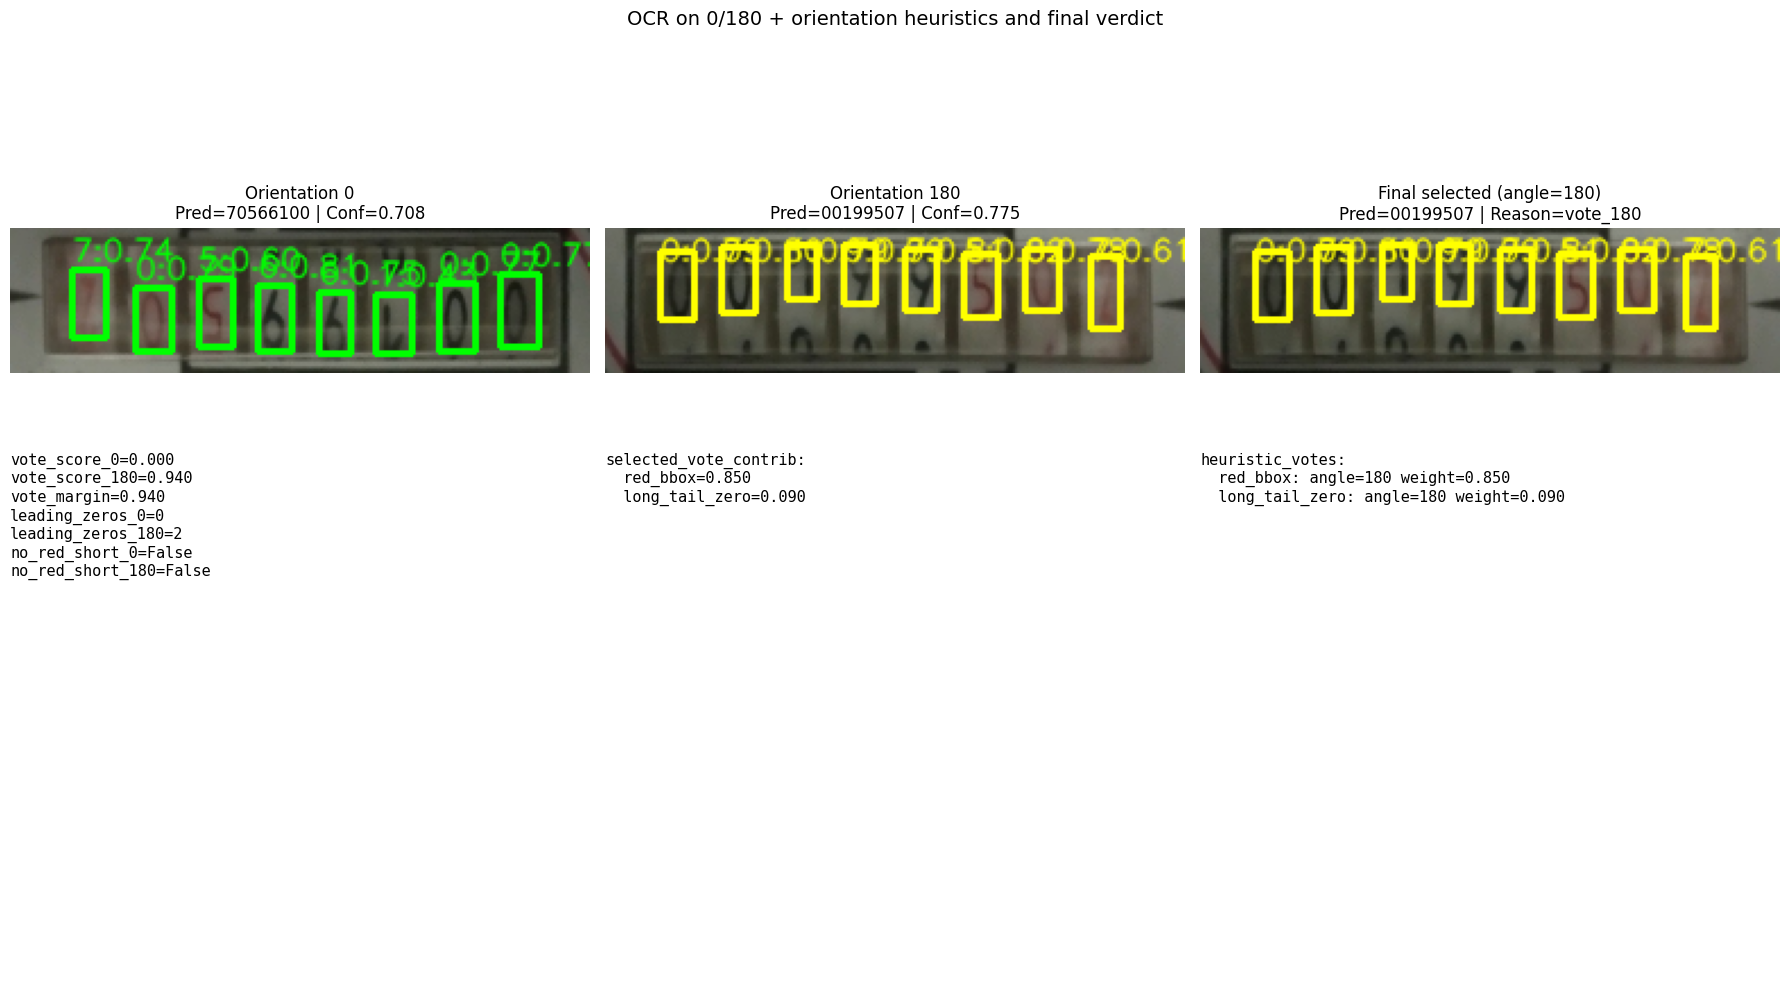

Predicted digits: 00199507


In [9]:
# Option A: set your own image path manually
# IMAGE_PATH = Path(r"C:/path/to/your/meter_image.jpg")

# Option B: pick one sample from WaterMeterDataset test split
_, wm_test = load_water_meter_dataset_split(WM_PATH, train_ratio=0.7, seed=42)
if not wm_test:
    raise RuntimeError(f"No samples found in: {WM_PATH}")

IMAGE_PATH = wm_test[0].image_path
print(f"Using IMAGE_PATH={IMAGE_PATH}")

result = run_single_image_pipeline(IMAGE_PATH, show_visualizations=True)
print("Predicted digits:", result["final_reading"])

## Batch run on full WM test split + comparison

This section runs the same bbox+ultralytics pipeline over all WaterMeterDataset test samples (`wm_bbox` path) and saves predictions in a CSV compatible with previous pilot runs.

By default it compares the new batch output with `all_predictions_yolo11m_model_only.csv` and reports improvements/regressions.

In [10]:
import re
from models.metrics.evaluation import per_digit_accuracy, character_error_rate


def digits_only(text):
    return "".join(ch for ch in str(text) if ch.isdigit())


def normalize_reading_digits(text):
    d = digits_only(text).lstrip("0")
    return d if d else "0"


def extract_wm_gt_digits(sample):
    value_text = getattr(sample, "value_text", None)
    if value_text:
        d = digits_only(value_text)
        if d:
            return d

    stem = Path(sample.image_path).stem
    m = re.search(r"_value_([0-9_]+)$", stem)
    if m:
        return m.group(1).replace("_", "")

    value = getattr(sample, "value", None)
    if value is not None:
        try:
            return digits_only(str(int(round(float(value)))))
        except Exception:
            pass

    return ""


def _positional_weights(length, base=2.0):
    if length <= 0:
        return []
    return [float(base ** (length - i - 1)) for i in range(length)]


def weighted_levenshtein_norm_error_rate(pred, gt, base=2.0):
    pred_norm = normalize_reading_digits(pred)
    gt_norm = normalize_reading_digits(gt)

    m = len(gt_norm)
    n = len(pred_norm)
    if m == 0 and n == 0:
        return 0.0

    w_gt = _positional_weights(m, base=base)
    w_pred = _positional_weights(n, base=base)

    dp = np.zeros((m + 1, n + 1), dtype=np.float64)
    for i in range(1, m + 1):
        dp[i, 0] = dp[i - 1, 0] + w_gt[i - 1]
    for j in range(1, n + 1):
        dp[0, j] = dp[0, j - 1] + w_pred[j - 1]

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            del_cost = dp[i - 1, j] + w_gt[i - 1]
            ins_cost = dp[i, j - 1] + w_pred[j - 1]
            if gt_norm[i - 1] == pred_norm[j - 1]:
                sub_cost = dp[i - 1, j - 1]
            else:
                sub_cost = dp[i - 1, j - 1] + max(w_gt[i - 1], w_pred[j - 1])
            dp[i, j] = min(del_cost, ins_cost, sub_cost)

    denom = max(sum(w_gt), sum(w_pred), 1.0)
    return float(dp[m, n] / denom)


def run_single_image_inference_quick(sample, roi_model=None, ocr_model=None):
    roi_model = roi_model or get_roi_model()
    ocr_model = ocr_model or get_ocr_model()

    image_path = Path(sample.image_path)
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        return {
            "sample_id": image_path.stem,
            "pred": "",
            "selected_angle": -1,
            "roi_conf": 0.0,
            "dt_ms": np.nan,
            "status": "read_error",
        }

    t0 = time.perf_counter()

    roi_info = detect_roi_bbox(image_bgr, roi_model)
    if roi_info is None:
        return {
            "sample_id": image_path.stem,
            "pred": "",
            "selected_angle": -1,
            "roi_conf": 0.0,
            "dt_ms": (time.perf_counter() - t0) * 1000.0,
            "status": "roi_miss",
        }

    bbox_debug = build_bbox_debug_stages(image_bgr, roi_info["bbox"], out_h=OUT_H, out_w=OUT_W)
    roi_crop_0 = bbox_debug["final_resized"]

    pred0 = predict_ocr_with_debug(roi_crop_0, ocr_model)
    roi_crop_180 = cv2.rotate(roi_crop_0, cv2.ROTATE_180)
    pred180 = predict_ocr_with_debug(roi_crop_180, ocr_model)

    selection = select_orientation_with_priors(pred0, pred180, roi_crop_0, ocr_model)

    return {
        "sample_id": image_path.stem,
        "pred": str(selection.get("selected_pred", "")),
        "selected_angle": int(selection.get("selected_angle", 0)),
        "roi_conf": float(roi_info.get("conf", 0.0)),
        "dt_ms": (time.perf_counter() - t0) * 1000.0,
        "status": "ok",
    }


def run_wm_bbox_batch_test(samples, progress_every=100):
    rows = []
    roi_model = get_roi_model()
    ocr_model = get_ocr_model()

    t_start = time.perf_counter()
    for idx, sample in enumerate(samples):
        gt = extract_wm_gt_digits(sample)
        out = run_single_image_inference_quick(sample, roi_model=roi_model, ocr_model=ocr_model)

        pred = out["pred"]
        gt_norm = normalize_reading_digits(gt)
        pred_norm = normalize_reading_digits(pred)

        rows.append(
            {
                "idx": idx,
                "sample_id": out["sample_id"],
                "split": "test",
                "crop_key": "wm_bbox",
                "candidate": "ultralytics_yolo11m_baseline",
                "preprocess_mode": "none",
                "gt": gt,
                "pred": pred,
                "gt_norm": gt_norm,
                "pred_norm": pred_norm,
                "ok_raw": pred == gt,
                "ok_norm": pred_norm == gt_norm,
                "ok_cmp": pred_norm == gt_norm,
                "selected_angle": out["selected_angle"],
                "dt_ms": float(out["dt_ms"]),
                "pda_i": float(per_digit_accuracy(pred, gt)),
                "cer_i": float(character_error_rate(pred, gt)),
                "wlev_norm_i": float(weighted_levenshtein_norm_error_rate(pred, gt, base=2.0)),
                "roi_conf": float(out["roi_conf"]),
                "status": out["status"],
            }
        )

        if progress_every and (idx + 1) % progress_every == 0:
            elapsed = time.perf_counter() - t_start
            print(f"Processed {idx + 1}/{len(samples)} samples in {elapsed:.1f}s")

    df = pd.DataFrame(rows)
    summary = pd.DataFrame([
        {
            "samples": int(len(df)),
            "ok_raw": float(df["ok_raw"].mean()),
            "ok_norm": float(df["ok_norm"].mean()),
            "avg_ms": float(df["dt_ms"].mean()),
            "non_empty_rate": float((df["pred"].astype(str) != "").mean()),
            "selected_180_share": float((df["selected_angle"] == 180).mean()),
            "roi_miss_rate": float((df["status"] == "roi_miss").mean()),
            "read_error_rate": float((df["status"] == "read_error").mean()),
        }
    ])
    return df, summary


def parse_bool_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .fillna(False)
    )


def compare_with_reference_csv(current_df, reference_csv_path):
    ref_path = Path(reference_csv_path)
    if not ref_path.exists():
        raise FileNotFoundError(f"Reference CSV not found: {ref_path}")

    ref = pd.read_csv(ref_path)
    cur = current_df.copy()

    cur["sample_id"] = cur["sample_id"].astype(str)
    ref["sample_id"] = ref["sample_id"].astype(str)

    ref = ref.rename(
        columns={
            "pred": "ref_pred",
            "ok_norm": "ref_ok_norm",
            "selected_angle": "ref_selected_angle",
            "dt_ms": "ref_dt_ms",
        }
    )

    merged = cur.merge(
        ref[["sample_id", "ref_pred", "ref_ok_norm", "ref_selected_angle", "ref_dt_ms"]],
        on="sample_id",
        how="left",
    )

    merged["ref_ok_norm"] = parse_bool_series(merged["ref_ok_norm"])
    merged["ref_pred"] = merged["ref_pred"].fillna("").astype(str)

    overlap_mask = merged["ref_dt_ms"].notna()
    overlap = merged[overlap_mask].copy()

    if overlap.empty:
        summary = pd.DataFrame([
            {
                "samples_current": int(len(cur)),
                "samples_ref_overlap": 0,
                "coverage": 0.0,
                "current_ok_norm": float(cur["ok_norm"].mean()),
                "ref_ok_norm": np.nan,
                "delta_ok_norm": np.nan,
                "pred_exact_match": np.nan,
                "angle_match": np.nan,
                "improved_count": 0,
                "regressed_count": 0,
                "current_avg_ms": float(cur["dt_ms"].mean()),
                "ref_avg_ms": np.nan,
                "speed_ratio_current_to_ref": np.nan,
            }
        ])
        return summary, merged, pd.DataFrame()

    overlap["same_pred"] = overlap["pred"] == overlap["ref_pred"]
    overlap["same_angle"] = overlap["selected_angle"].astype(str) == overlap["ref_selected_angle"].astype(str)
    overlap["improved"] = (~overlap["ref_ok_norm"]) & overlap["ok_norm"]
    overlap["regressed"] = overlap["ref_ok_norm"] & (~overlap["ok_norm"])

    summary = pd.DataFrame([
        {
            "samples_current": int(len(cur)),
            "samples_ref_overlap": int(len(overlap)),
            "coverage": float(len(overlap) / max(len(cur), 1)),
            "current_ok_norm": float(overlap["ok_norm"].mean()),
            "ref_ok_norm": float(overlap["ref_ok_norm"].mean()),
            "delta_ok_norm": float(overlap["ok_norm"].mean() - overlap["ref_ok_norm"].mean()),
            "pred_exact_match": float(overlap["same_pred"].mean()),
            "angle_match": float(overlap["same_angle"].mean()),
            "improved_count": int(overlap["improved"].sum()),
            "regressed_count": int(overlap["regressed"].sum()),
            "current_avg_ms": float(overlap["dt_ms"].mean()),
            "ref_avg_ms": float(pd.to_numeric(overlap["ref_dt_ms"], errors="coerce").mean()),
            "speed_ratio_current_to_ref": float(
                overlap["dt_ms"].mean() / max(pd.to_numeric(overlap["ref_dt_ms"], errors="coerce").mean(), 1e-9)
            ),
        }
    ])

    changed = overlap[(~overlap["same_pred"]) | (~overlap["same_angle"])].copy()
    changed = changed.sort_values(["regressed", "improved", "sample_id"], ascending=[False, False, True])

    return summary, merged, changed

In [11]:
# Run full WM test split in batch mode and compare with reference CSV.

BATCH_OUT_DIR = ROOT / "results/ocr_pretrained_failures_single_image_pipeline/ultralytics_yolo11m_baseline/none/test/wm_bbox"
BATCH_OUT_DIR.mkdir(parents=True, exist_ok=True)
BATCH_OUT_CSV = BATCH_OUT_DIR / "all_predictions_single_image_pipeline.csv"

REFERENCE_CSV = ROOT / "results/ocr_pretrained_failures_yolo11m_model_only/ultralytics_yolo11m_baseline/none/test/wm_bbox/all_predictions_yolo11m_model_only.csv"

_, wm_test = load_water_meter_dataset_split(WM_PATH, train_ratio=0.7, seed=42)
print(f"Test samples: {len(wm_test)}")

batch_df, batch_summary_df = run_wm_bbox_batch_test(wm_test, progress_every=100)
batch_df.to_csv(BATCH_OUT_CSV, index=False)

print(f"Saved batch predictions: {BATCH_OUT_CSV}")
display(batch_summary_df)
display(batch_df.head(10))

cmp_summary_df, cmp_merged_df, cmp_changed_df = compare_with_reference_csv(batch_df, REFERENCE_CSV)

print(f"Compared with: {REFERENCE_CSV}")
display(cmp_summary_df)

if cmp_changed_df.empty:
    print("No prediction/angle differences vs reference on overlapping sample_id set.")
else:
    keep_cols = [
        "sample_id", "gt", "pred", "ref_pred", "ok_norm", "ref_ok_norm",
        "selected_angle", "ref_selected_angle", "dt_ms", "ref_dt_ms", "improved", "regressed",
    ]
    display(cmp_changed_df[keep_cols].head(40))

Test samples: 374
Processed 100/374 samples in 17.6s
Processed 200/374 samples in 37.1s
Processed 300/374 samples in 58.3s
Saved batch predictions: C:\Users\alike\WaterMeterCV\results\ocr_pretrained_failures_single_image_pipeline\ultralytics_yolo11m_baseline\none\test\wm_bbox\all_predictions_single_image_pipeline.csv


,samples,ok_raw,ok_norm,avg_ms,non_empty_rate,selected_180_share,roi_miss_rate,read_error_rate
0,374,0.0,0.807487,181.834132,0.997326,0.05615,0.0,0.0


,idx,sample_id,split,crop_key,candidate,preprocess_mode,gt,pred,gt_norm,pred_norm,ok_raw,ok_norm,ok_cmp,selected_angle,dt_ms,pda_i,cer_i,wlev_norm_i,roi_conf,status
0,0,id_586_value_199_502,test,wm_bbox,ultralytics_yolo11m_baseline,none,199502,00199507,199502,199507,False,False,False,180,237.4913,0.000,0.500000,0.015873,0.850358,ok
1,1,id_1117_value_101_299,test,wm_bbox,ultralytics_yolo11m_baseline,none,101299,00101299,101299,101299,False,True,True,0,352.9514,0.250,0.333333,0.000000,0.925641,ok
2,2,id_1045_value_122_269,test,wm_bbox,ultralytics_yolo11m_baseline,none,122269,00122269,122269,122269,False,True,True,0,173.3631,0.125,0.333333,0.000000,0.913310,ok
3,3,id_1000_value_176_881,test,wm_bbox,ultralytics_yolo11m_baseline,none,176881,0017688,176881,17688,False,False,False,180,148.4826,0.000,0.500000,0.015873,0.831884,ok
4,4,id_682_value_247_055,test,wm_bbox,ultralytics_yolo11m_baseline,none,247055,00247055,247055,247055,False,True,True,0,144.2230,0.000,0.333333,0.000000,0.939450,ok
5,5,id_509_value_156_0,test,wm_bbox,ultralytics_yolo11m_baseline,none,1560,00156,1560,156,False,False,False,0,137.2075,0.000,0.750000,0.066667,0.935088,ok
6,6,id_565_value_248_164,test,wm_bbox,ultralytics_yolo11m_baseline,none,248164,00248164,248164,248164,False,True,True,180,142.6032,0.000,0.333333,0.000000,0.879332,ok
7,7,id_726_value_114_147,test,wm_bbox,ultralytics_yolo11m_baseline,none,114147,00114147,114147,114147,False,True,True,0,133.3574,0.250,0.333333,0.000000,0.909738,ok
8,8,id_898_value_136_669,test,wm_bbox,ultralytics_yolo11m_baseline,none,136669,00136669,136669,136669,False,True,True,0,156.8159,0.125,0.333333,0.000000,0.925431,ok
9,9,id_315_value_195_419,test,wm_bbox,ultralytics_yolo11m_baseline,none,195419,00195419,195419,195419,False,True,True,0,192.8223,0.000,0.333333,0.000000,0.936912,ok


Compared with: C:\Users\alike\WaterMeterCV\results\ocr_pretrained_failures_yolo11m_model_only\ultralytics_yolo11m_baseline\none\test\wm_bbox\all_predictions_yolo11m_model_only.csv


,samples_current,samples_ref_overlap,coverage,current_ok_norm,ref_ok_norm,delta_ok_norm,pred_exact_match,angle_match,improved_count,regressed_count,current_avg_ms,ref_avg_ms,speed_ratio_current_to_ref
0,374,374,1.0,0.807487,0.877005,-0.069519,0.002674,0.994652,1,27,181.834132,41.013995,4.433466


,sample_id,gt,pred,ref_pred,ok_norm,ref_ok_norm,selected_angle,ref_selected_angle,dt_ms,ref_dt_ms,improved,regressed
122,id_142_value_641_39,64139,00641390,641390.0,False,True,0,0,219.0891,40.5896,False,True
230,id_214_value_138_49,13849,00138490,138490.0,False,True,0,0,209.6571,37.2105,False,True
263,id_217_value_865_65,86565,00865650,865650.0,False,True,0,0,348.4890,37.9774,False,True
315,id_220_value_366_68,36668,00366680,366680.0,False,True,0,0,135.4282,39.4396,False,True
359,id_231_value_0_7,07,00000700,700.0,False,True,0,0,124.7946,39.0145,False,True
50,id_249_value_706_0,7060,00706,706.0,False,True,0,0,200.6799,36.2074,False,True
338,id_251_value_36_0,360,00036,36.0,False,True,0,0,166.3094,39.3461,False,True
155,id_288_value_49_28,4928,00049280,49280.0,False,True,0,0,123.8510,39.5305,False,True
124,id_407_value_21_86,2186,00021860,21860.0,False,True,180,180,252.5386,38.4904,False,True
174,id_415_value_262_0,2620,00262,262.0,False,True,0,0,98.9112,38.2299,False,True
